# 파일 불러오기

- [메인] smartphone (분석용)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("2019-Oct.csv")

In [2]:
# 지수 -> 소수점(2) 표기
pd.options.display.float_format = '{:.2f}'.format

In [3]:
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [4]:
print(df.shape)

(42448764, 9)


In [5]:
smartphone_df = df[df['category_code'] == 'electronics.smartphone'].copy()

In [ ]:
chunk_iter = pd.read_csv("2019-Nov.csv", chunksize=1000000)
smartphone_chunks = []

for chunk in chunk_iter:
    filtered = chunk[chunk['category_code'] == 'electronics.smartphone'].copy()
    smartphone_chunks.append(filtered)
    
smartphone_df2 = pd.concat(smartphone_chunks, axis=0)

In [7]:
print(smartphone_df.shape)
print(smartphone_df2.shape)

(11507231, 9)
(16375000, 9)


In [8]:
df = smartphone_df
df2 = smartphone_df2

del smartphone_df

In [9]:
import gc
gc.collect()

20

In [10]:
print(df.shape)
print(df2.shape)

(11507231, 9)
(16375000, 9)


In [ ]:
# def optimize_memory(df):
#     for col in df.columns:
#         if df[col].dtype == 'float64':
#             df[col] = df[col].astype('float32')
#         if df[col].dtype == 'int64':
#             df[col] = df[col].astype('int32')
#     return df

# df = optimize_memory(df)
# df2 = optimize_memory(df2)

# 데이터 확인

### 기본

In [12]:
print(df.head())
print(df.shape)

                 event_time event_type  product_id  category_id  \
4   2019-10-01 00:00:04 UTC       view     1004237  -1769995873   
9   2019-10-01 00:00:11 UTC       view     1004545  -1769995873   
11  2019-10-01 00:00:11 UTC       view     1005011  -1769995873   
19  2019-10-01 00:00:19 UTC       view     1005135  -1769995873   
20  2019-10-01 00:00:20 UTC       view     1003306  -1769995873   

             category_code    brand   price    user_id  \
4   electronics.smartphone    apple 1081.98  535871217   
9   electronics.smartphone   huawei  566.01  537918940   
11  electronics.smartphone  samsung  900.64  530282093   
19  electronics.smartphone    apple 1747.79  535871217   
20  electronics.smartphone    apple  588.77  555446831   

                            user_session  
4   c6bd7419-2748-4c56-95b4-8cec9ff8b80d  
9   406c46ed-90a4-4787-a43b-59a410c1a5fb  
11  50a293fb-5940-41b2-baf3-17af0e812101  
19  c6bd7419-2748-4c56-95b4-8cec9ff8b80d  
20  6ec635da-ea15-4a5d-96b4-c8ca9

In [13]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 11507231 entries, 4 to 42448757
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int32  
 3   category_id    int32  
 4   category_code  str    
 5   brand          str    
 6   price          float32
 7   user_id        int32  
 8   user_session   str    
dtypes: float32(1), int32(3), str(5)
memory usage: 1.7 GB
None


In [14]:
print(df2.head())
print(df2.shape)

                 event_time event_type  product_id  category_id  \
0   2019-11-01 00:00:00 UTC       view     1003461  -1769995873   
4   2019-11-01 00:00:01 UTC       view     1004775  -1769995873   
9   2019-11-01 00:00:02 UTC       view     1004258  -1769995873   
18  2019-11-01 00:00:07 UTC       view     1004566  -1769995873   
21  2019-11-01 00:00:08 UTC       view     1004708  -1769995873   

             category_code   brand  price    user_id  \
0   electronics.smartphone  xiaomi 489.07  520088904   
4   electronics.smartphone  xiaomi 183.27  558856683   
9   electronics.smartphone   apple 732.07  532647354   
18  electronics.smartphone  huawei 164.84  566265908   
21  electronics.smartphone  huawei 151.99  566143627   

                            user_session  
0   4d3b30da-a5e4-49df-b1a8-ba5943f1dd33  
4   313628f1-68b8-460d-84f6-cec7a8796ef2  
9   d2d3d2c6-631d-489e-9fb5-06f340b85be0  
18  52c2c76c-b79e-4794-86ff-badc76d35f5a  
21  aa610ab3-5c60-4551-8a2b-8c999dddf843  
(1

In [15]:
print(df2.info())

<class 'pandas.DataFrame'>
Index: 16375000 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int32  
 3   category_id    int32  
 4   category_code  str    
 5   brand          str    
 6   price          float32
 7   user_id        int32  
 8   user_session   str    
dtypes: float32(1), int32(3), str(5)
memory usage: 2.4 GB
None


In [16]:
print(df.columns.tolist())

['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


In [17]:
print(df.isna().sum())
print("------")
print(df2.isna().sum())

event_time           0
event_type           0
product_id           0
category_id          0
category_code        0
brand            21910
price                0
user_id              0
user_session         1
dtype: int64
------
event_time           0
event_type           0
product_id           0
category_id          0
category_code        0
brand            21418
price                0
user_id              0
user_session         3
dtype: int64


In [18]:
print(df.isna().mean() * 100)
print("------")
print(df2.isna().mean() * 100)

event_time      0.00
event_type      0.00
product_id      0.00
category_id     0.00
category_code   0.00
brand           0.19
price           0.00
user_id         0.00
user_session    0.00
dtype: float64
------
event_time      0.00
event_type      0.00
product_id      0.00
category_id     0.00
category_code   0.00
brand           0.13
price           0.00
user_id         0.00
user_session    0.00
dtype: float64


In [19]:
print(df.duplicated().sum())
print("------")
print(df2.duplicated().sum())

18597
------
41016


In [20]:
print(df.nunique())
print("------")
print(df2.nunique())

event_time       2360196
event_type             3
product_id          1285
category_id            1
category_code          1
brand                 41
price              11362
user_id          1300236
user_session     3099337
dtype: int64
------
event_time       2350876
event_type             3
product_id          1341
category_id            1
category_code          1
brand                 42
price               8596
user_id          1575532
user_session     4209586
dtype: int64


In [21]:
print(df['category_code'].isna().sum())
print(df2['category_code'].isna().sum())

0
0


In [22]:
print(df['brand'].isna().sum())
print(df2['brand'].isna().sum())

21910
21418


In [23]:
df[~df['category_code'].isna()].head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
4,2019-10-01 00:00:04 UTC,view,1004237,-1769995873,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
9,2019-10-01 00:00:11 UTC,view,1004545,-1769995873,electronics.smartphone,huawei,566.01,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb
11,2019-10-01 00:00:11 UTC,view,1005011,-1769995873,electronics.smartphone,samsung,900.64,530282093,50a293fb-5940-41b2-baf3-17af0e812101
19,2019-10-01 00:00:19 UTC,view,1005135,-1769995873,electronics.smartphone,apple,1747.79,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
20,2019-10-01 00:00:20 UTC,view,1003306,-1769995873,electronics.smartphone,apple,588.77,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f
23,2019-10-01 00:00:23 UTC,view,1004739,-1769995873,electronics.smartphone,xiaomi,197.55,519530528,9882d21f-2c5f-496b-90d4-a1503edb6562
25,2019-10-01 00:00:24 UTC,view,1003306,-1769995873,electronics.smartphone,apple,588.77,555446831,6ec635da-ea15-4a5d-96b4-c8ca9d38f89f
49,2019-10-01 00:00:36 UTC,view,1004767,-1769995873,electronics.smartphone,samsung,254.82,512558158,9a206ba2-37c7-4354-9d31-37ff3bb297ed
51,2019-10-01 00:00:41 UTC,view,1003141,-1769995873,electronics.smartphone,apple,382.97,551377651,ca11a570-47da-4630-898b-9a03127703da
54,2019-10-01 00:00:43 UTC,view,1005135,-1769995873,electronics.smartphone,apple,1747.79,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [24]:
df['event_type'].value_counts()

event_type
view        10619448
cart          549765
purchase      338018
Name: count, dtype: int64

In [25]:
df['brand'].value_counts()

brand
samsung       3778167
apple         3272845
xiaomi        2200549
huawei        1001883
oppo           482887
meizu          155562
vivo           113205
honor           76915
nokia           70639
sony            67481
oneplus         65871
lg              24125
tp-link         22664
bq              20797
doogee          18177
inoi            16575
google          15436
prestigio       14298
haier           11053
zte             10762
asus             6617
tecno            5933
jinga            4472
gionee           4038
umi              3724
blackberry       3686
irbis            3483
htc              3312
fly              2922
nubia            2099
texet            1291
leeco            1046
vertex            916
micromax          673
philips           625
oukitel           235
leagoo            207
hiper              67
ark                60
motorola           23
bravis              1
Name: count, dtype: int64

### 브랜드

In [26]:
brand_view = (
    df[df['event_type'] == 'view']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='view_count')
)

brand_view.head(10)

,brand,view_count
0,samsung,3386871
1,apple,2991772
2,xiaomi,2094234
3,huawei,940176
4,oppo,451449
5,meizu,152984
6,vivo,108180
7,honor,75499
8,nokia,69428
9,sony,66547


In [27]:
brand_view2 = (
    df2[df2['event_type'] == 'view']
    .groupby('brand')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='view_count')
)

brand_view2.head(10)

,brand,view_count
0,samsung,4693069
1,apple,4159400
2,xiaomi,3094384
3,huawei,1149180
4,oppo,751991
5,meizu,193813
6,vivo,151502
7,oneplus,107359
8,honor,105059
9,nokia,91209


In [28]:
#비율
brand_view_ratio = brand_view.copy()
brand_view_ratio['ratio'] = brand_view_ratio['view_count'] / brand_view_ratio['view_count'].sum()

brand_view_ratio2 = brand_view2.copy()
brand_view_ratio2['ratio'] = brand_view_ratio2['view_count'] / brand_view_ratio2['view_count'].sum()

print(brand_view_ratio.head(10))
print("------")
print(brand_view_ratio2.head(10))

     brand  view_count  ratio
0  samsung     3386871   0.32
1    apple     2991772   0.28
2   xiaomi     2094234   0.20
3   huawei      940176   0.09
4     oppo      451449   0.04
5    meizu      152984   0.01
6     vivo      108180   0.01
7    honor       75499   0.01
8    nokia       69428   0.01
9     sony       66547   0.01
------
     brand  view_count  ratio
0  samsung     4693069   0.32
1    apple     4159400   0.28
2   xiaomi     3094384   0.21
3   huawei     1149180   0.08
4     oppo      751991   0.05
5    meizu      193813   0.01
6     vivo      151502   0.01
7  oneplus      107359   0.01
8    honor      105059   0.01
9    nokia       91209   0.01


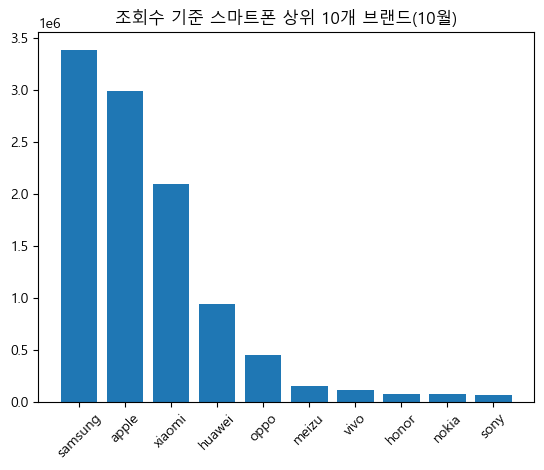

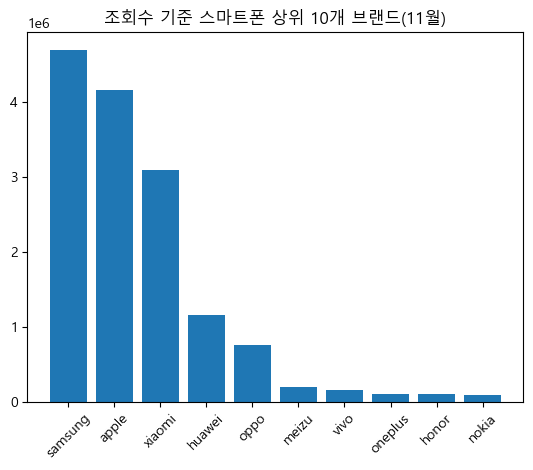

In [29]:
top10 = brand_view.head(10)

plt.figure()
plt.bar(top10['brand'], top10['view_count'])
plt.xticks(rotation=45)
plt.title('조회수 기준 스마트폰 상위 10개 브랜드(10월)')
plt.show()

top10_2 = brand_view2.head(10)

plt.figure()
plt.bar(top10_2['brand'], top10_2['view_count'])
plt.xticks(rotation=45)
plt.title('조회수 기준 스마트폰 상위 10개 브랜드(11월)')
plt.show()

# 기본 전처리

In [30]:
# 중복 제거
df = df.drop_duplicates()
df2 = df2.drop_duplicates()

In [31]:
# 브랜드 결측치 (unknown)
df['brand'] = df['brand'].fillna('unknown')
df2['brand'] = df2['brand'].fillna('unknown')

In [32]:
# category_code 결측치 (unknown)
df['category_code'] = df['category_code'].fillna('unknown')
df2['category_code'] = df2['category_code'].fillna('unknown')

### 날짜

In [33]:
df['event_time'].head()

4     2019-10-01 00:00:04 UTC
9     2019-10-01 00:00:11 UTC
11    2019-10-01 00:00:11 UTC
19    2019-10-01 00:00:19 UTC
20    2019-10-01 00:00:20 UTC
Name: event_time, dtype: str

In [34]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True).dt.tz_convert('Asia/Seoul').dt.tz_localize(None)
df2['event_time'] = pd.to_datetime(df2['event_time'], utc=True).dt.tz_convert('Asia/Seoul').dt.tz_localize(None)

# datetime으로 타입 변환, utc → 한국 시간으로 변환

### 통계적 이상치 제거

1. 반복구매 이상치 후보 플래그
    - 동일고객이 동일세션에서 동일한 상품을 반복해서 구매할때
- 카테고리별 중복구매수 iqr 상한값을 구한 후
- 동일유저 + 동일상품 + 동일 세션에서 각 카테고리별 상한값 초과 반복 구매한 세션 중 짧은시간(0~60초) 안에 재 구매한 세션을 최종 이상후보 세션이라고 가정
- 단순 중복과 통계적 이상치 구분(근거는 최종 통합 코드에만 첨부)

In [35]:
### 10월 (purchase_sess_out_10)
### 기준:
### 1. 동일 유저 + 동일 상품 + 동일 세션 기준 구매 횟수 집계
### 2. 2회 이상 반복구매 조합 전체에서 카테고리별 IQR 상한값 계산
### 3. IQR 상한값 초과 조합 추출
### 4. IQR 초과 + 60초 미만 재구매 조합 추출
### 5. IQR 초과 + view/cart 없이 purchase만 반복된 조합도 최종 후보에 포함


# -------------------------------------------------
# 1. purchase 행만 필요한 컬럼으로 추출
# -------------------------------------------------

df_purchase_10 = df.loc[
    df['event_type'] == 'purchase',
    ['user_id', 'product_id', 'user_session', 'event_time', 'event_type', 'category_code']
].copy()

df_purchase_10['category_code'] = df_purchase_10['category_code'].fillna('unknown')


# -------------------------------------------------
# 2. 동일 유저 + 동일 상품 + 동일 세션 기준 구매 정보 집계
#    mode() 대신 first() 사용
# -------------------------------------------------

purchase_sess_10 = (
    df_purchase_10
    .groupby(['user_id', 'product_id', 'user_session'], as_index=False)
    .agg(
        buy_cnt=('event_type', 'size'),
        category_code=('category_code', 'first')
    )
)


# -------------------------------------------------
# 3. 2회 이상 반복 구매한 경우만 추출
# -------------------------------------------------

purchase_sess_2_10 = purchase_sess_10[
    purchase_sess_10['buy_cnt'] >= 2
].copy()


# -------------------------------------------------
# 4. 카테고리별 반복 구매수 IQR 상한값 계산
# -------------------------------------------------

cat_iqr_10 = (
    purchase_sess_2_10
    .groupby('category_code')['buy_cnt']
    .quantile([0.25, 0.75])
    .unstack()
    .reset_index()
)

cat_iqr_10.columns = ['category_code', 'q1', 'q3']
cat_iqr_10['iqr'] = cat_iqr_10['q3'] - cat_iqr_10['q1']
cat_iqr_10['upper'] = cat_iqr_10['q3'] + 1.5 * cat_iqr_10['iqr']


# -------------------------------------------------
# 5. purchase_sess_2_10에 카테고리별 upper 붙이기
# -------------------------------------------------

purchase_sess_2_10 = purchase_sess_2_10.merge(
    cat_iqr_10[['category_code', 'upper']],
    on='category_code',
    how='left'
)


# -------------------------------------------------
# 6. 카테고리별 IQR 상한값 초과 조합 추출
# -------------------------------------------------

purchase_sess_out_iqr_10 = purchase_sess_2_10[
    purchase_sess_2_10['buy_cnt'] > purchase_sess_2_10['upper']
].copy()


# -------------------------------------------------
# 7. IQR 초과 후보 조합의 purchase 로그만 가져와 시간 간격 계산
# -------------------------------------------------

iqr_pairs_10 = purchase_sess_out_iqr_10[
    ['user_id', 'product_id', 'user_session']
].drop_duplicates()

df_purchase_out_10 = df_purchase_10[
    ['user_id', 'product_id', 'user_session', 'event_time']
].merge(
    iqr_pairs_10,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)

df_purchase_out_10 = df_purchase_out_10.sort_values(
    ['user_id', 'product_id', 'user_session', 'event_time']
)

df_purchase_out_10['prev_time'] = df_purchase_out_10.groupby(
    ['user_id', 'product_id', 'user_session']
)['event_time'].shift(1)

df_purchase_out_10['gap_sec'] = (
    df_purchase_out_10['event_time'] - df_purchase_out_10['prev_time']
).dt.total_seconds()


# -------------------------------------------------
# 8. IQR 초과 후보 중 60초 미만 재구매 조합 추출
#    기준: 0초 이상 60초 미만
# -------------------------------------------------

short_gap_sessions_10 = df_purchase_out_10.loc[
    (df_purchase_out_10['gap_sec'] >= 0) &
    (df_purchase_out_10['gap_sec'] < 60),
    ['user_id', 'product_id', 'user_session']
].drop_duplicates()


# -------------------------------------------------
# 9. IQR 초과 후보 중 view/cart 없이 purchase만 반복된 조합 추출
# -------------------------------------------------

out_log_10 = df[
    ['user_id', 'product_id', 'user_session', 'event_type']
].merge(
    iqr_pairs_10,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)

out_check_10 = (
    out_log_10
    .groupby(['user_id', 'product_id', 'user_session', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['view', 'cart', 'purchase']:
    if col not in out_check_10.columns:
        out_check_10[col] = 0

out_purchase_only_10 = out_check_10[
    (out_check_10['view'] == 0) &
    (out_check_10['cart'] == 0) &
    (out_check_10['purchase'] >= 2)
][['user_id', 'product_id', 'user_session']].copy()


# -------------------------------------------------
# 10. 최종 반복구매 이상치 후보
#     1) IQR 초과 + 60초 미만 재구매
#     2) IQR 초과 + view/cart 없이 purchase만 반복
# -------------------------------------------------

purchase_sess_out_gap_10 = purchase_sess_out_iqr_10.merge(
    short_gap_sessions_10,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
).copy()

purchase_sess_out_gap_10['outlier_reason'] = 'iqr_over_and_gap_0_60_under'


purchase_sess_out_purchase_only_10 = purchase_sess_out_iqr_10.merge(
    out_purchase_only_10,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
).copy()

purchase_sess_out_purchase_only_10['outlier_reason'] = 'iqr_over_and_purchase_only'


purchase_sess_out_10 = pd.concat(
    [
        purchase_sess_out_gap_10,
        purchase_sess_out_purchase_only_10
    ],
    ignore_index=True
)

purchase_sess_out_10 = purchase_sess_out_10.drop_duplicates(
    subset=['user_id', 'product_id', 'user_session']
).copy()


# -------------------------------------------------
# 11. 확인 출력
# -------------------------------------------------

print("동일 유저 + 동일 상품 + 동일 세션 기준 2회 이상 반복 구매 조합 수:", len(purchase_sess_2_10))
print("카테고리별 IQR 상한값 초과 조합 수:", len(purchase_sess_out_iqr_10))
print("IQR 상한값 초과 + 60초 미만 재구매 조합 수:", len(purchase_sess_out_gap_10))
print("IQR 상한값 초과 + view/cart 없이 purchase만 반복된 조합 수:", len(purchase_sess_out_purchase_only_10))
print("최종 반복구매 이상치 후보 조합 수:", len(purchase_sess_out_10))
print("전체 2회 이상 조합 대비 최종 후보 비율:", round(len(purchase_sess_out_10) / len(purchase_sess_2_10) * 100, 2), "%")

display(purchase_sess_out_10.head())

동일 유저 + 동일 상품 + 동일 세션 기준 2회 이상 반복 구매 조합 수: 22534
카테고리별 IQR 상한값 초과 조합 수: 4155
IQR 상한값 초과 + 60초 미만 재구매 조합 수: 1578
IQR 상한값 초과 + view/cart 없이 purchase만 반복된 조합 수: 0
최종 반복구매 이상치 후보 조합 수: 1578
전체 2회 이상 조합 대비 최종 후보 비율: 7.0 %


,user_id,product_id,user_session,buy_cnt,category_code,upper,outlier_reason
0,512363879,1003312,83db5b5a-2638-4296-b2d9-463dd589ecaa,4,electronics.smartphone,2.00,iqr_over_and_gap_0_60_under
1,512375395,1004249,da3455de-8f46-4340-9be9-ddf9d72b2644,3,electronics.smartphone,2.00,iqr_over_and_gap_0_60_under
2,512379865,1005115,148c1f91-7648-4d6e-8aec-fad18c63c698,3,electronics.smartphone,2.00,iqr_over_and_gap_0_60_under
3,512382536,1002544,5a5532c9-dfb6-458e-bcf3-c0b072135957,3,electronics.smartphone,2.00,iqr_over_and_gap_0_60_under
4,512384696,1004653,b46d3e3f-ad82-46e7-af35-468ac2a7d7ed,3,electronics.smartphone,2.00,iqr_over_and_gap_0_60_under


In [36]:
# -------------------------------------------------
# 10월 - 반복구매 이상치 후보 조합 삭제 시 영향 행 수 확인
# 기준:
# 후보 조합 안에서 마지막 purchase 시점까지의
# view/cart/purchase 전체를 산정
# -------------------------------------------------

# 1. 최종 이상치 후보 조합만 추출
candidate_pairs_10 = purchase_sess_out_10[
    ['user_id', 'product_id', 'user_session']
].drop_duplicates().copy()

print("10월 반복구매 이상치 후보 조합 수:", len(candidate_pairs_10))


# 2. 원본 df에서 후보 조합에 해당하는 로그만 추출
#    전체 df에 MultiIndex 만들지 않고, 필요한 컬럼만 merge
df_outlier_logs_10 = df[
    ['user_id', 'product_id', 'user_session', 'event_time', 'event_type']
].merge(
    candidate_pairs_10,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)


# 3. 후보 조합별 첫 purchase / 마지막 purchase 시점 계산
purchase_time_range_10 = (
    df_outlier_logs_10[df_outlier_logs_10['event_type'] == 'purchase']
    .groupby(['user_id', 'product_id', 'user_session'])['event_time']
    .agg(
        first_purchase_time='min',
        last_purchase_time='max'
    )
    .reset_index()
)


# 4. 첫/마지막 purchase 시점 붙이기
df_outlier_logs_10 = df_outlier_logs_10.merge(
    purchase_time_range_10,
    on=['user_id', 'product_id', 'user_session'],
    how='left'
)


# 5. 마지막 purchase 시점까지의 로그만 산정
#    첫 purchase 이전 view/cart + 반복 purchase 사이 view/cart + purchase 전체 포함
target_logs_10 = df_outlier_logs_10[
    df_outlier_logs_10['event_time'] <= df_outlier_logs_10['last_purchase_time']
].copy()


# 6. event_type별 행 수
outlier_remove_impact_10_range = (
    target_logs_10['event_type']
    .value_counts()
    .reindex(['view', 'cart', 'purchase'], fill_value=0)
    .reset_index()
)

outlier_remove_impact_10_range.columns = ['event_type', 'row_count']

outlier_remove_impact_10_range['count_rule'] = [
    '후보 조합에서 마지막 purchase 시점까지의 view 산정',
    '후보 조합에서 마지막 purchase 시점까지의 cart 산정',
    '후보 조합의 purchase 전체 산정'
]

outlier_remove_impact_10_range = outlier_remove_impact_10_range[
    ['event_type', 'count_rule', 'row_count']
]


print("10월 반복구매 이상치 후보 조합 삭제 시 영향 행 수")
display(outlier_remove_impact_10_range)

10월 반복구매 이상치 후보 조합 수: 1578
10월 반복구매 이상치 후보 조합 삭제 시 영향 행 수


,event_type,count_rule,row_count
0,view,후보 조합에서 마지막 purchase 시점까지의 view 산정,7428
1,cart,후보 조합에서 마지막 purchase 시점까지의 cart 산정,3903
2,purchase,후보 조합의 purchase 전체 산정,6007


In [37]:
### 11월 (purchase_sess_out_11) - 메모리 절약 버전
### 기준:
### 1. 동일 유저 + 동일 상품 + 동일 세션 기준 구매 횟수 집계
### 2. 2회 이상 반복구매 조합 전체에서 카테고리별 IQR 상한값 계산
### 3. IQR 상한값 초과 조합 추출
### 4. 그 후보 조합 안에서 50초 미만 재구매가 있는 조합 추출
### 5. IQR 초과 후보 중 view/cart 없이 purchase만 반복된 조합도 최종 후보에 포함


# -------------------------------------------------
# 1. purchase 행만 필요한 컬럼으로 추출
# -------------------------------------------------

df_purchase_11 = df2.loc[
    df2['event_type'] == 'purchase',
    ['user_id', 'product_id', 'user_session', 'event_time', 'event_type', 'category_code']
].copy()

df_purchase_11['category_code'] = df_purchase_11['category_code'].fillna('unknown')


# -------------------------------------------------
# 2. 동일 유저 + 동일 상품 + 동일 세션 기준 구매 횟수 집계
#    mode() 대신 first() 사용해서 속도 개선
# -------------------------------------------------

purchase_sess_11 = (
    df_purchase_11
    .groupby(['user_id', 'product_id', 'user_session'], as_index=False)
    .agg(
        buy_cnt=('event_type', 'size'),
        category_code=('category_code', 'first')
    )
)


# -------------------------------------------------
# 3. 2회 이상 반복 구매한 경우만 추출
# -------------------------------------------------

purchase_sess_2_11 = purchase_sess_11[
    purchase_sess_11['buy_cnt'] >= 2
].copy()


# -------------------------------------------------
# 4. 카테고리별 IQR 상한값 계산
# -------------------------------------------------

cat_iqr_11 = (
    purchase_sess_2_11
    .groupby('category_code')['buy_cnt']
    .quantile([0.25, 0.75])
    .unstack()
    .reset_index()
)

cat_iqr_11.columns = ['category_code', 'q1', 'q3']
cat_iqr_11['iqr'] = cat_iqr_11['q3'] - cat_iqr_11['q1']
cat_iqr_11['upper'] = cat_iqr_11['q3'] + 1.5 * cat_iqr_11['iqr']


# -------------------------------------------------
# 5. IQR 상한값 붙이기
# -------------------------------------------------

purchase_sess_2_11 = purchase_sess_2_11.merge(
    cat_iqr_11[['category_code', 'upper']],
    on='category_code',
    how='left'
)


# -------------------------------------------------
# 6. IQR 상한값 초과 조합 추출
# -------------------------------------------------

purchase_sess_out_iqr_11 = purchase_sess_2_11[
    purchase_sess_2_11['buy_cnt'] > purchase_sess_2_11['upper']
].copy()


# -------------------------------------------------
# 7. IQR 초과 후보의 purchase 로그만 추출
#    전체 df2가 아니라 df_purchase_11에서만 merge
# -------------------------------------------------

iqr_pairs_11 = purchase_sess_out_iqr_11[
    ['user_id', 'product_id', 'user_session']
].drop_duplicates()

df_purchase_out_11 = df_purchase_11[
    ['user_id', 'product_id', 'user_session', 'event_time']
].merge(
    iqr_pairs_11,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)


# -------------------------------------------------
# 8. purchase 간격 계산
# -------------------------------------------------

df_purchase_out_11 = df_purchase_out_11.sort_values(
    ['user_id', 'product_id', 'user_session', 'event_time']
)

df_purchase_out_11['prev_time'] = df_purchase_out_11.groupby(
    ['user_id', 'product_id', 'user_session']
)['event_time'].shift(1)

df_purchase_out_11['gap_sec'] = (
    df_purchase_out_11['event_time'] - df_purchase_out_11['prev_time']
).dt.total_seconds()


# -------------------------------------------------
# 9. IQR 초과 후보 중 50초 미만 재구매 조합 추출
#    기준: 0초 이상 50초 미만
# -------------------------------------------------

short_gap_sessions_11 = df_purchase_out_11.loc[
    (df_purchase_out_11['gap_sec'] >= 0) &
    (df_purchase_out_11['gap_sec'] < 50),
    ['user_id', 'product_id', 'user_session']
].drop_duplicates()


# -------------------------------------------------
# 10. IQR 초과 후보 중 view/cart 없이 purchase만 반복된 조합 추출
#     전체 df2에 MultiIndex 만들지 말고, 필요한 컬럼만 merge
# -------------------------------------------------

out_log_11 = df2[
    ['user_id', 'product_id', 'user_session', 'event_type']
].merge(
    iqr_pairs_11,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)

out_check_11 = (
    out_log_11
    .groupby(['user_id', 'product_id', 'user_session', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['view', 'cart', 'purchase']:
    if col not in out_check_11.columns:
        out_check_11[col] = 0

out_purchase_only_11 = out_check_11[
    (out_check_11['view'] == 0) &
    (out_check_11['cart'] == 0) &
    (out_check_11['purchase'] >= 2)
][['user_id', 'product_id', 'user_session']].copy()


# -------------------------------------------------
# 11. 최종 반복구매 이상치 후보
#     1) IQR 초과 + 50초 미만 재구매
#     2) IQR 초과 + view/cart 없이 purchase만 반복
# -------------------------------------------------

purchase_sess_out_gap_11 = purchase_sess_out_iqr_11.merge(
    short_gap_sessions_11,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
).copy()

purchase_sess_out_gap_11['outlier_reason'] = 'iqr_over_and_gap_0_50_under'


purchase_sess_out_purchase_only_11 = purchase_sess_out_iqr_11.merge(
    out_purchase_only_11,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
).copy()

purchase_sess_out_purchase_only_11['outlier_reason'] = 'iqr_over_and_purchase_only'


purchase_sess_out_11 = pd.concat(
    [purchase_sess_out_gap_11, purchase_sess_out_purchase_only_11],
    ignore_index=True
)

purchase_sess_out_11 = purchase_sess_out_11.drop_duplicates(
    subset=['user_id', 'product_id', 'user_session']
).copy()


# -------------------------------------------------
# 12. 확인 출력
# -------------------------------------------------

print("동일 유저 + 동일 상품 + 동일 세션 기준 2회 이상 반복 구매 조합 수:", len(purchase_sess_2_11))
print("카테고리별 IQR 상한값 초과 조합 수:", len(purchase_sess_out_iqr_11))
print("IQR 상한값 초과 + 50초 미만 재구매 조합 수:", len(purchase_sess_out_gap_11))
print("IQR 상한값 초과 + view/cart 없이 purchase만 반복된 조합 수:", len(purchase_sess_out_purchase_only_11))
print("최종 반복구매 이상치 후보 조합 수:", len(purchase_sess_out_11))
print("전체 2회 이상 조합 대비 최종 후보 비율:", round(len(purchase_sess_out_11) / len(purchase_sess_2_11) * 100, 2), "%")

display(purchase_sess_out_11.head())

동일 유저 + 동일 상품 + 동일 세션 기준 2회 이상 반복 구매 조합 수: 23720
카테고리별 IQR 상한값 초과 조합 수: 4509
IQR 상한값 초과 + 50초 미만 재구매 조합 수: 748
IQR 상한값 초과 + view/cart 없이 purchase만 반복된 조합 수: 1
최종 반복구매 이상치 후보 조합 수: 749
전체 2회 이상 조합 대비 최종 후보 비율: 3.16 %


,user_id,product_id,user_session,buy_cnt,category_code,upper,outlier_reason
0,512363921,1005212,14045d9a-02e2-4ffb-8059-468d4a1421aa,3,electronics.smartphone,2.00,iqr_over_and_gap_0_50_under
1,512396132,1005124,3151e95b-0243-4422-bae5-7628f85c4ca6,3,electronics.smartphone,2.00,iqr_over_and_gap_0_50_under
2,512432519,1004767,8351c062-f244-47bd-b16c-b9cdf037e947,3,electronics.smartphone,2.00,iqr_over_and_gap_0_50_under
3,512443301,1004872,1d5acb63-8605-4943-9540-734b78d747a2,3,electronics.smartphone,2.00,iqr_over_and_gap_0_50_under
4,512445284,1005115,24d38509-35a5-47b7-9114-6de81b1aae18,3,electronics.smartphone,2.00,iqr_over_and_gap_0_50_under


In [38]:
# -------------------------------------------------
# 11월 - 반복구매 이상치 후보 조합 삭제 시 영향 행 수 확인
# 기준:
# 후보 조합 안에서 마지막 purchase 시점까지의
# view/cart/purchase 전체를 산정
# -------------------------------------------------

# 1. 최종 이상치 후보 조합만 추출
candidate_pairs_11 = purchase_sess_out_11[
    ['user_id', 'product_id', 'user_session']
].drop_duplicates().copy()

print("11월 반복구매 이상치 후보 조합 수:", len(candidate_pairs_11))


# 2. 원본 df2에서 후보 조합에 해당하는 로그만 추출
#    전체 df2에 MultiIndex 만들지 않고, 필요한 컬럼만 merge
df_outlier_logs_11 = df2[
    ['user_id', 'product_id', 'user_session', 'event_time', 'event_type']
].merge(
    candidate_pairs_11,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)


# 3. 후보 조합별 첫 purchase / 마지막 purchase 시점 계산
purchase_time_range_11 = (
    df_outlier_logs_11[df_outlier_logs_11['event_type'] == 'purchase']
    .groupby(['user_id', 'product_id', 'user_session'])['event_time']
    .agg(
        first_purchase_time='min',
        last_purchase_time='max'
    )
    .reset_index()
)


# 4. 첫/마지막 purchase 시점 붙이기
df_outlier_logs_11 = df_outlier_logs_11.merge(
    purchase_time_range_11,
    on=['user_id', 'product_id', 'user_session'],
    how='left'
)


# 5. 마지막 purchase 시점까지의 로그만 산정
#    첫 purchase 이전 view/cart + 반복 purchase 사이 view/cart + purchase 전체 포함
target_logs_11 = df_outlier_logs_11[
    df_outlier_logs_11['event_time'] <= df_outlier_logs_11['last_purchase_time']
].copy()


# 6. event_type별 행 수
outlier_remove_impact_11_range = (
    target_logs_11['event_type']
    .value_counts()
    .reindex(['view', 'cart', 'purchase'], fill_value=0)
    .reset_index()
)

outlier_remove_impact_11_range.columns = ['event_type', 'row_count']

outlier_remove_impact_11_range['count_rule'] = [
    '후보 조합에서 마지막 purchase 시점까지의 view 산정',
    '후보 조합에서 마지막 purchase 시점까지의 cart 산정',
    '후보 조합의 purchase 전체 산정'
]

outlier_remove_impact_11_range = outlier_remove_impact_11_range[
    ['event_type', 'count_rule', 'row_count']
]


print("11월 반복구매 이상치 후보 조합 삭제 시 영향 행 수")
display(outlier_remove_impact_11_range)

11월 반복구매 이상치 후보 조합 수: 749
11월 반복구매 이상치 후보 조합 삭제 시 영향 행 수


,event_type,count_rule,row_count
0,view,후보 조합에서 마지막 purchase 시점까지의 view 산정,3553
1,cart,후보 조합에서 마지막 purchase 시점까지의 cart 산정,2925
2,purchase,후보 조합의 purchase 전체 산정,3102


2. price (통계적 이상치)
- price가 0 이하인 행들 데이터 누락 판단(삭제 유보) → 플래그 유지 + 목적별 처리

In [39]:
# 가격 이상치 및 결측치 (IQR 방식 계산)

# 10월
q1_10 = df['price'].quantile(0.25)
q3_10 = df['price'].quantile(0.75)
upper_10 = q3_10 + 3.0 * (q3_10 - q1_10)

df['is_price_error'] = (
    (df['price'] <= 0) | 
    (df['price'].isna()) | 
    (df['price'] > upper_10)
)

# 11월
q1_11 = df2['price'].quantile(0.25)
q3_11 = df2['price'].quantile(0.75)
upper_11 = q3_11 + 3.0 * (q3_11 - q1_11)

df2['is_price_error'] = (
    (df2['price'] <= 0) | 
    (df2['price'].isna()) | 
    (df2['price'] > upper_11)
)

# 파생변수

### 날짜 파생변수
- 시 / 요일 / 요일명
- 시간대

In [40]:
df['hour'] = df['event_time'].dt.hour #시 추출
df['day_of_week'] = df['event_time'].dt.dayofweek  # 0=월요일, 6=일요일
df['day_name'] = df['event_time'].dt.day_name() #영문 이름 붙이기

In [41]:
df2['hour'] = df2['event_time'].dt.hour #시 추출
df2['day_of_week'] = df2['event_time'].dt.dayofweek  # 0=월요일, 6=일요일
df2['day_name'] = df2['event_time'].dt.day_name() #영문 이름 붙이기

In [42]:
# 시간대
def time_segment(hour):
    if 6 <= hour < 12:
        return '오전 (6-12시)'
    elif 12 <= hour < 18:
        return '오후 (12-18시)'
    elif 18 <= hour < 24:
        return '저녁 (18-24시)'
    else:
        return '새벽 (0-6시)'

df['time_segment'] = df['hour'].apply(time_segment)
print(df['time_segment'].value_counts())

time_segment
저녁 (18-24시)    3894712
오후 (12-18시)    3478159
새벽 (0-6시)      3398238
오전 (6-12시)      717525
Name: count, dtype: int64


In [43]:
# 시간대
def time_segment(hour):
    if 6 <= hour < 12:
        return '오전 (6-12시)'
    elif 12 <= hour < 18:
        return '오후 (12-18시)'
    elif 18 <= hour < 24:
        return '저녁 (18-24시)'
    else:
        return '새벽 (0-6시)'

df2['time_segment'] = df2['hour'].apply(time_segment)
print(df2['time_segment'].value_counts())

time_segment
저녁 (18-24시)    5596686
오후 (12-18시)    4851033
새벽 (0-6시)      4791508
오전 (6-12시)     1094757
Name: count, dtype: int64


### 반복구매 이상치 후보 플래그

In [44]:
# -------------------------------------------------
# [10월] 반복구매 이상치 후보 플래그 생성 - 가벼운 버전
# 기준:
# 후보 조합 안에서 마지막 purchase 시점까지의 view/cart/purchase는 True
# -------------------------------------------------

df = df.drop(columns=['is_outlier'], errors='ignore')

candidate_pairs_10 = purchase_sess_out_10[
    ['user_id', 'product_id', 'user_session']
].drop_duplicates().copy()

print("10월 반복구매 이상치 후보 조합 수:", len(candidate_pairs_10))

# 후보 조합의 purchase 로그만 가져와 마지막 purchase 시점 계산
df_candidate_purchase_10 = df[
    ['user_id', 'product_id', 'user_session', 'event_time', 'event_type']
].merge(
    candidate_pairs_10,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)

last_purchase_time_10 = (
    df_candidate_purchase_10[df_candidate_purchase_10['event_type'] == 'purchase']
    .groupby(['user_id', 'product_id', 'user_session'])['event_time']
    .max()
    .reset_index(name='last_purchase_time')
)

# 원본 df에 마지막 purchase 시점만 붙이고 조건으로 플래그 생성
df = df.merge(
    last_purchase_time_10,
    on=['user_id', 'product_id', 'user_session'],
    how='left'
)

df['is_outlier'] = (
    df['last_purchase_time'].notna() &
    df['event_type'].isin(['view', 'cart', 'purchase']) &
    (df['event_time'] <= df['last_purchase_time'])
)

df = df.drop(columns=['last_purchase_time'], errors='ignore')

print("10월 is_outlier 플래그 분포")
print(df['is_outlier'].value_counts(dropna=False))

print("10월 is_outlier=True 행의 event_type 분포")
print(df.loc[df['is_outlier'], 'event_type'].value_counts(dropna=False))

10월 반복구매 이상치 후보 조합 수: 1578
10월 is_outlier 플래그 분포
is_outlier
False    11471296
True        17338
Name: count, dtype: int64
10월 is_outlier=True 행의 event_type 분포
event_type
view        7428
purchase    6007
cart        3903
Name: count, dtype: int64


In [45]:
# -------------------------------------------------
# [11월] 반복구매 이상치 후보 플래그 생성 - 가벼운 버전
# 기준:
# 1) purchase_sess_out_11에 포함된 user_id + product_id + user_session 조합
# 2) 후보 조합 안에서 마지막 purchase 시점까지의 view/cart/purchase는 True
# 3) 마지막 purchase 이후 view/cart는 False
# 4) 후보 조합이 아닌 행은 False
# 5) 최종 컬럼명은 is_outlier
# -------------------------------------------------

# 기존 플래그 제거
df2 = df2.drop(columns=['is_outlier'], errors='ignore')


# 1. 최종 이상치 후보 조합
candidate_pairs_11 = purchase_sess_out_11[
    ['user_id', 'product_id', 'user_session']
].drop_duplicates()


# 2. 후보 조합의 purchase 로그만 추출
#    전체 로그를 merge하지 않고 purchase만 사용해서 가볍게 처리
candidate_purchase_11 = df2.loc[
    df2['event_type'].eq('purchase'),
    ['user_id', 'product_id', 'user_session', 'event_time']
].merge(
    candidate_pairs_11,
    on=['user_id', 'product_id', 'user_session'],
    how='inner'
)


# 3. 후보 조합별 마지막 purchase 시점 계산
last_purchase_time_11 = (
    candidate_purchase_11
    .groupby(['user_id', 'product_id', 'user_session'], as_index=False)['event_time']
    .max()
    .rename(columns={'event_time': 'last_purchase_time'})
)


# 4. 원본 df2에 마지막 purchase 시점만 붙이기
df2 = df2.merge(
    last_purchase_time_11,
    on=['user_id', 'product_id', 'user_session'],
    how='left'
)


# 5. 마지막 purchase 시점까지의 view/cart/purchase만 True
df2['is_outlier'] = (
    df2['last_purchase_time'].notna() &
    df2['event_type'].isin(['view', 'cart', 'purchase']) &
    (df2['event_time'] <= df2['last_purchase_time'])
)


# 6. 임시 컬럼 제거
df2 = df2.drop(columns=['last_purchase_time'], errors='ignore')


# 확인
print("11월 is_outlier 플래그 분포")
print(df2['is_outlier'].value_counts(dropna=False))

print("11월 is_outlier=True 행의 event_type 분포")
print(df2.loc[df2['is_outlier'], 'event_type'].value_counts(dropna=False))

11월 is_outlier 플래그 분포
is_outlier
False    16324404
True         9580
Name: count, dtype: int64
11월 is_outlier=True 행의 event_type 분포
event_type
view        3553
purchase    3102
cart        2925
Name: count, dtype: int64


In [46]:
df_final = df.loc[df['is_outlier'] == False].copy()
df2_final = df2.loc[df2['is_outlier'] == False].copy()

### 상태 식별 플래그(is~) / 활동량 집계 변수(total~)

In [47]:
### 상태 식별 플래그 (is~)
df_final['is_purchase'] = (df_final['event_type'] == 'purchase').astype(int)
df_final['is_cart'] = (df_final['event_type'] == 'cart').astype(int)

df2_final['is_purchase'] = (df2_final['event_type'] == 'purchase').astype(int)
df2_final['is_cart'] = (df2_final['event_type'] == 'cart').astype(int)

print(df_final['is_purchase'].sum())
print(df_final['is_cart'].sum())
print("------")
print(df2_final['is_purchase'].sum())
print(df2_final['is_cart'].sum())

331972
528104
------
379544
1116466


In [48]:
# 평균으로 확률 도출 
print(df_final['is_purchase'].mean().round(3))
print(df2_final['is_purchase'].mean().round(3))

0.029
0.023


In [49]:
### 활동량 집계 변수 (total~)

total_view = (df_final['event_type'] == 'view').sum()
total_cart = df_final['is_cart'].sum()
total_purchase = df_final['is_purchase'].sum()

# 검증용
len_evt = total_view + total_cart + total_purchase


total_view2 = (df2_final['event_type'] == 'view').sum()
total_cart2 = df2_final['is_cart'].sum()
total_purchase2 = df2_final['is_purchase'].sum()

# 검증용
len_evt2 = total_view2 + total_cart2 + total_purchase2

print(len_evt)
print(df_final['event_type'].shape)
print("------")
print(len_evt2)
print(df2_final['event_type'].shape)

11471296
(11471296,)
------
16324404
(16324404,)


### 결측 패턴 탐색 (category_code & brand)

In [50]:
# category_code
yes_unknown = df_final[df_final['category_code'] == 'unknown'].copy()
no_unknown = df_final[df_final['category_code'] != 'unknown'].copy()

yes_unknown2 = df2_final[df2_final['category_code'] == 'unknown'].copy()
no_unknown2 = df2_final[df2_final['category_code'] != 'unknown'].copy()

In [51]:
# 전환율 비교
yes_unknown_cv = yes_unknown['is_purchase'].mean()
no_unknown_cv = no_unknown['is_purchase'].mean()

yes_unknown_cv2 = yes_unknown2['is_purchase'].mean()
no_unknown_cv2 = no_unknown2['is_purchase'].mean()

print(yes_unknown_cv)
print(no_unknown_cv.round(4))
print("------")
print(yes_unknown_cv2)
print(no_unknown_cv2.round(4))

nan
0.0289
------
nan
0.0233


In [52]:
# brand
yes_brand = df_final[df_final['brand'] != 'unknown'].copy()
no_brand = df_final[df_final['brand'] == 'unknown'].copy()

yes_brand2 = df2_final[df2_final['brand'] != 'unknown'].copy()
no_brand2 = df2_final[df2_final['brand'] == 'unknown'].copy()

print(f"브랜드 있는 그룹 전환율(10월): {yes_brand['is_purchase'].mean():.4f}")
print(f"브랜드 없는 그룹 전환율(10월): {no_brand['is_purchase'].mean():.4f}")
print("------")
print(f"브랜드 있는 그룹 전환율(11월): {yes_brand2['is_purchase'].mean():.4f}")
print(f"브랜드 없는 그룹 전환율(11월): {no_brand2['is_purchase'].mean():.4f}")

브랜드 있는 그룹 전환율(10월): 0.0290
브랜드 없는 그룹 전환율(10월): 0.0201
------
브랜드 있는 그룹 전환율(11월): 0.0233
브랜드 없는 그룹 전환율(11월): 0.0073


### 메인 퍼널(실제 상품 단위) - funnel_df

In [53]:
# 그룹화
grouped = df_final.groupby(['user_session', 'product_id'])
grouped2 = df2_final.groupby(['user_session', 'product_id'])

In [54]:
# 메인 퍼널 로직 (10월)

result = []
for (session, product_id), group in grouped:
    group = group.sort_values('event_time')  
    events = group['event_type'].tolist()

    
    # index 찾기
    view_idx = next((i for i, e in enumerate(events) if e == 'view'), None)
    cart_idx = next((i for i, e in enumerate(events) if e == 'cart'), None)
    purchase_idx = next((i for i, e in enumerate(events) if e == 'purchase'), None)
    
    has_view = view_idx is not None
    valid_view_cart = view_idx is not None and cart_idx is not None and view_idx < cart_idx
    valid_cart_purchase = cart_idx is not None and purchase_idx is not None and cart_idx < purchase_idx
    
    result.append([
        session, product_id,
        has_view,
        valid_view_cart,
        valid_cart_purchase
    ])

funnel_df = pd.DataFrame(result, columns=[
    'user_session', 'product_id',
    'view', 'view_to_cart', 'cart_to_purchase'
])

In [55]:
# 메인 퍼널 로직 (11월)

result2 = []
for (session, product_id), group in grouped2:
    group = group.sort_values('event_time')  
    events = group['event_type'].tolist()

    
    # index 찾기
    view_idx = next((i for i, e in enumerate(events) if e == 'view'), None)
    cart_idx = next((i for i, e in enumerate(events) if e == 'cart'), None)
    purchase_idx = next((i for i, e in enumerate(events) if e == 'purchase'), None)
    
    has_view = view_idx is not None
    valid_view_cart = view_idx is not None and cart_idx is not None and view_idx < cart_idx
    valid_cart_purchase = cart_idx is not None and purchase_idx is not None and cart_idx < purchase_idx
    
    result2.append([
        session, product_id,
        has_view,
        valid_view_cart,
        valid_cart_purchase
    ])

funnel_df2 = pd.DataFrame(result2, columns=[
    'user_session', 'product_id',
    'view', 'view_to_cart', 'cart_to_purchase'
])

## 브랜드 단위 세션 퍼널 - brand_funnel

- user_session + brand : 브랜드 단위 세션 퍼널
    - 브랜드 관심도/브랜드 내 전환

In [56]:
### 브랜드별 세션 단위의 행동 집계

In [57]:
# 세션별 행동 집계 (10월)
brand_session_activity = (
    df_final.groupby(['user_session', 'brand'])
    .agg(
        view_count=('event_type', lambda x: (x == 'view').sum()),
        cart_count=('event_type', lambda x: (x == 'cart').sum()),
        purchase_count=('event_type', lambda x: (x == 'purchase').sum())
    )
    .reset_index()
)

In [58]:
# 세션별 행동 집계 (11월)
brand_session_activity2 = (
    df2_final.groupby(['user_session', 'brand'])
    .agg(
        view_count=('event_type', lambda x: (x == 'view').sum()),
        cart_count=('event_type', lambda x: (x == 'cart').sum()),
        purchase_count=('event_type', lambda x: (x == 'purchase').sum())
    )
    .reset_index()
)

### 브랜드별 퍼널 집계 및 전환율 계산
- 브랜드별 퍼널 집계 및 전환율 계산

In [ ]:
### 10월
# 브랜드별 세션 기반 전환 집계
brand_funnel = (
    funnel_df.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel['view_to_cart_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['view_to_cart_sessions'] / brand_funnel['view_sessions'],
    0
)

brand_funnel['cart_to_purchase_rate'] = np.where(
    brand_funnel['view_to_cart_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_to_cart_sessions'],
    0
)

brand_funnel['total_conversion_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_sessions'],
    0
)

# 이탈률
brand_funnel['drop_view_to_cart'] = 1 - brand_funnel['view_to_cart_rate']
brand_funnel['drop_cart_to_purchase'] = 1 - brand_funnel['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue = (
    df_final[df_final['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis = brand_funnel.merge(
    brand_revenue,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis = brand_analysis.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis[rate_cols] = brand_analysis[rate_cols] * 100

brand_analysis.head(20)

In [ ]:
### 11월
# 브랜드별 세션 기반 전환 집계
brand_funnel2 = (
    funnel_df2.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel2['view_to_cart_rate'] = np.where(
    brand_funnel2['view_sessions'] > 0,
    brand_funnel2['view_to_cart_sessions'] / brand_funnel2['view_sessions'],
    0
)

brand_funnel2['cart_to_purchase_rate'] = np.where(
    brand_funnel2['view_to_cart_sessions'] > 0,
    brand_funnel2['cart_to_purchase_sessions'] / brand_funnel2['view_to_cart_sessions'],
    0
)

brand_funnel2['total_conversion_rate'] = np.where(
    brand_funnel2['view_sessions'] > 0,
    brand_funnel2['cart_to_purchase_sessions'] / brand_funnel2['view_sessions'],
    0
)

# 이탈률
brand_funnel2['drop_view_to_cart'] = 1 - brand_funnel2['view_to_cart_rate']
brand_funnel2['drop_cart_to_purchase'] = 1 - brand_funnel2['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel2 = brand_funnel2[brand_funnel2['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue2 = (
    df2_final[df2_final['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis2 = brand_funnel2.merge(
    brand_revenue2,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis2 = brand_analysis2.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis2[rate_cols] = brand_analysis2[rate_cols] * 100

brand_analysis2.head(20)

In [ ]:
### 10월
# 브랜드별 퍼널 집계 및 전환율 계산
brand_funnel = (
    funnel_df.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel['view_to_cart_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['view_to_cart_sessions'] / brand_funnel['view_sessions'],
    0
)

brand_funnel['cart_to_purchase_rate'] = np.where(
    brand_funnel['view_to_cart_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_to_cart_sessions'],
    0
)

brand_funnel['total_conversion_rate'] = np.where(
    brand_funnel['view_sessions'] > 0,
    brand_funnel['cart_to_purchase_sessions'] / brand_funnel['view_sessions'],
    0
)

# 이탈률
brand_funnel['drop_view_to_cart'] = 1 - brand_funnel['view_to_cart_rate']
brand_funnel['drop_cart_to_purchase'] = 1 - brand_funnel['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel = brand_funnel[brand_funnel['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue = (
    df_final[df_final['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis = brand_funnel.merge(
    brand_revenue,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis = brand_analysis.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis[rate_cols] = brand_analysis[rate_cols] * 100

brand_analysis.head(20)

In [ ]:
### 11월
# 브랜드별 퍼널 집계 및 전환율 계산
brand_funnel2 = (
    funnel_df2.groupby('brand')
    .agg(
        view_sessions=('view', 'sum'),
        view_to_cart_sessions=('view_to_cart', 'sum'),
        cart_to_purchase_sessions=('cart_to_purchase', 'sum')
    )
    .reset_index()
)

# 전환율 계산
brand_funnel2['view_to_cart_rate'] = np.where(
    brand_funnel2['view_sessions'] > 0,
    brand_funnel2['view_to_cart_sessions'] / brand_funnel2['view_sessions'],
    0
)

brand_funnel2['cart_to_purchase_rate'] = np.where(
    brand_funnel2['view_to_cart_sessions'] > 0,
    brand_funnel2['cart_to_purchase_sessions'] / brand_funnel2['view_to_cart_sessions'],
    0
)

brand_funnel2['total_conversion_rate'] = np.where(
    brand_funnel2['view_sessions'] > 0,
    brand_funnel2['cart_to_purchase_sessions'] / brand_funnel2['view_sessions'],
    0
)

# 이탈률
brand_funnel2['drop_view_to_cart'] = 1 - brand_funnel2['view_to_cart_rate']
brand_funnel2['drop_cart_to_purchase'] = 1 - brand_funnel2['cart_to_purchase_rate']

# 표본 적은 브랜드 제거
brand_funnel2 = brand_funnel2[brand_funnel2['view_sessions'] >= 100].copy()

# 매출 데이터 결합
brand_revenue2 = (
    df2_final[df2_final['event_type'] == 'purchase']
    .groupby('brand')
    .agg(
        revenue=('price', 'sum'),
        purchase_count=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

brand_analysis2 = brand_funnel2.merge(
    brand_revenue2,
    on='brand',
    how='left'
).fillna(0)

# 보기 좋게 정렬
brand_analysis2 = brand_analysis2.sort_values(
    by='total_conversion_rate',
    ascending=False
)

# 퍼센트 변환
rate_cols = [
    'view_to_cart_rate',
    'cart_to_purchase_rate',
    'total_conversion_rate',
    'drop_view_to_cart',
    'drop_cart_to_purchase'
]

brand_analysis2[rate_cols] = brand_analysis2[rate_cols] * 100

brand_analysis2.head(20)

# 기타

In [ ]:
# 전처리 근거 및 EDA는 최종 코드 파일에만 넣고 전처리 파일에는 넣지 않았습니다!
# 풀 이후 copy해서 파일명 변경 후 작업 붙여넣어주시면 됩니다! 화이팅입니다~!

# 정보
### [데이터 흐름도]
- df - df_final - funnel_df (퍼널 분석 시) / brand_funnel (브랜드 단위 분석 시)

### [데이터 딕셔너리]
| 파생변수명                   | 의미                          |
| ----------------------- | --------------------------- |
| `hour`                  | 이벤트 발생 시간대(0~23시)           |
| `day_of_week`           | 이벤트 발생 요일 정보                |
| `time_segment`          | 시간대를 새벽/오전/오후/저녁으로 구간화한 변수  |
| `is_purchase`           | 구매 이벤트 여부(1=구매, 0=구매 외)       |
| `is_cart`               | 장바구니 이벤트 여부(1=장바구니, 0=장바구니 외)   |
| `gap_sec`               | 동일 상품 재방문·재구매까지 걸린 시간 간격(초) |
| `buy_cnt`               | 세션 내 동일 상품 구매 횟수            |
| `view_to_cart_rate`     | 조회 대비 장바구니 전환율              |
| `cart_to_purchase_rate` | 장바구니 대비 구매 전환율              |
| `total_conversion_rate` | 조회 대비 최종 구매 전환율             |
| `drop_view_to_cart`     | 조회 후 장바구니 진입 전 이탈률          |
| `drop_cart_to_purchase` | 장바구니 후 구매 전 이탈률             |
| `revenue`               | 총 구매 금액(매출)                 |
| `purchase_count`        | 총 구매 건수                     |
| `avg_price`             | 평균 구매 가격                    |
| `is_outlier`            | 비정상적 반복 구매 여부(이상치 플래그)      |
| `is_price_error`        | 가격 오류·결측·극단값 여부             |


# 앞으로 진행할 통계 분석
- 단계별 전환율 분석
    - 전환율(단계별 소비자 행동의 전환 비중)
        - 메인 퍼널 전환에 영향을 미치는 주요 독립 변수 간의 상관성 분석
        - 유저 분포 / 리텐션 커브 / 요일별 흐름 / 구매~이탈 소요 시간 코호트 분석
    - 단계별 병목 구간 특정 및 이탈 주요 영향 변수 탐색
    - 시계열 패턴 및 구매 도달시간으로 교차 탐색 빈도 추적
        - 시간대별/요일별/월별 소비자의 교차 탐색 빈도 추적
        - 구매 고려 시간(12h/24h/36h) & 최종 구매 도달시간
- 고객 세그먼트 분석
    - 세션 내 행동 데이터를 바탕으로 소비자 유형 그룹(탐색형 vs 충성형 vs 대중형 고객 심리 세그먼트)과 앞서 만든 시간대별 파생변수들과 결합하여 특징과 행동 패턴 파악 (전환 속도, 주요 구매 시간대 등)
- 브랜드 세그먼트 분석
    - 비즈니스 관점에서의 브랜드 세그먼트(시장 지배형 vs 프리미엄 수익형 vs 비교형)
    - 소비자의 ‘브랜드 교차 탐색 활동’ 추적 및 시간대별 교차탐색빈도 분석 결과와 비교

In [ ]:
# =================================================
# 최종 전처리 완료 CSV 저장
# =================================================

# 10월 전처리 완료 파일 저장
df_final.to_csv(
    "2019-Oct_smartphone_preprocessed_final.csv",
    index=False,
    encoding="utf-8-sig"
)

# 11월 전처리 완료 파일 저장
df2_final.to_csv(
    "2019-Nov_smartphone_preprocessed_final.csv",
    index=False,
    encoding="utf-8-sig"
)

print("10월 전처리 완료 CSV 저장 완료")
print("11월 전처리 완료 CSV 저장 완료")